In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
import matplotlib.pyplot as plt

RANDOM_STATE = 42


## 1) Load your dataset
Update the path below to your CSV file. The UCI Cleveland target column is `num`.


In [4]:
#this path to where your CSV is stored
DATA_PATH = "heart_disease_uci.csv"
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
display(df.dtypes)

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

## 2) Clean and prepare target
- Replace '?' with NaN (some UCI versions use '?')
- Convert columns to numeric where possible
- Convert `num` to binary: 0 = no disease, 1 = disease (1–4)


In [8]:
# Replace '?' with NaN if present
df = df.replace('?', np.nan)

# Convert columns that look numeric into numeric (keeps strings as-is)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='ignore')
    

# Confirm target exists
assert 'num' in df.columns, "Target column 'num' not found. Check your dataset columns."

# Convert target to binary: 0 stays 0, 1-4 becomes 1
df['num'] = df['num'].apply(lambda x: 0 if x == 0 else 1)

print('Target distribution (0=no disease, 1=disease):')
print(df['num'].value_counts(dropna=False))

# Quick missing values check
print('\nMissing values per column:')
print(df.isna().sum())


Target distribution (0=no disease, 1=disease):
num
1    509
0    411
Name: count, dtype: int64

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


/var/folders/9k/z5cknj9j3jdc56sdnyy1cz8m0000gn/T/ipykernel_55182/3978506856.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors='ignore')


## 3) Split features (X) and target (y)


In [9]:
X = df.drop(columns=['num'])
y = df['num']

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (920, 15)
y shape: (920,)


## 4) Build preprocessing
We handle:
- Numeric columns: impute missing with median + scale
- Categorical columns: impute missing + one-hot encode


In [10]:
# Identify column types
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)


Numeric columns: ['id', 'age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca']
Categorical columns: ['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal']


## 5) Train/test split (stratified)
`stratify=y` keeps the same 0/1 balance in train and test.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('Train target distribution:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test target distribution:', y_test.value_counts(normalize=True).round(3).to_dict())


Train target distribution: {1: 0.553, 0: 0.447}
Test target distribution: {1: 0.554, 0: 0.446}


## 6) Baseline model: Logistic Regression


Classification report (Logistic Regression):
              precision    recall  f1-score   support

           0      0.857     0.805     0.830        82
           1      0.850     0.892     0.871       102

    accuracy                          0.853       184
   macro avg      0.854     0.849     0.851       184
weighted avg      0.853     0.853     0.853       184

Confusion matrix:
[[66 16]
 [11 91]]
ROC-AUC: 0.9346


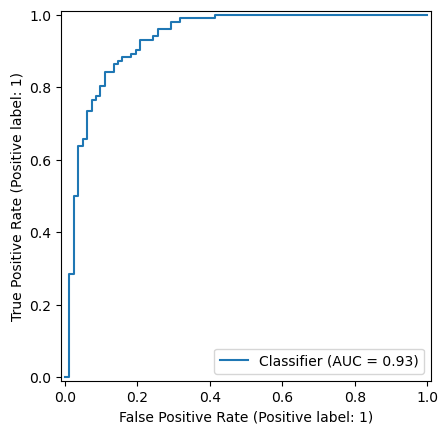

In [12]:
log_reg = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print('Classification report (Logistic Regression):')
print(classification_report(y_test, y_pred, digits=3))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba), 4))

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()


## 7) Compare multiple baseline models (with cross-validation)
We use Stratified K-Fold CV for stable, fair evaluation.


In [13]:
models = {
    'LogReg': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'NaiveBayes': GaussianNB(),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

rows = []
for name, clf in models.items():
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', clf)])
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({
        'Model': name,
        'Accuracy (mean)': float(np.mean(scores['test_accuracy'])),
        'Precision (mean)': float(np.mean(scores['test_precision'])),
        'Recall (mean)': float(np.mean(scores['test_recall'])),
        'F1 (mean)': float(np.mean(scores['test_f1'])),
        'ROC-AUC (mean)': float(np.mean(scores['test_roc_auc'])),
        'Accuracy (std)': float(np.std(scores['test_accuracy']))
    })

results = pd.DataFrame(rows).sort_values('ROC-AUC (mean)', ascending=False)
display(results)


,Model,Accuracy (mean),Precision (mean),Recall (mean),F1 (mean),ROC-AUC (mean),Accuracy (std)
4,RandomForest,0.868478,0.863504,0.905824,0.883464,0.935641,0.024402
0,LogReg,0.851087,0.854973,0.880256,0.866884,0.917653,0.037433
2,SVM-RBF,0.843478,0.836136,0.892021,0.862865,0.913230,0.018318
3,NaiveBayes,0.820652,0.848334,0.823238,0.835378,0.890480,0.010312
1,DecisionTree,0.808696,0.840633,0.809610,0.822771,0.808787,0.033923
